# Lab 055 · TabReD: the temporal-split reality

**Skill:** audit and implement an evaluation protocol that matches future deployment. No new model is introduced. The load-bearing split, preprocessing, selection and rank operations are visible and editable. The existing L054 MLP and TabM-mini implementations and their trainer are also visible below.

[Lesson](../lessons/0055-tabred-temporal-splits.html) · [Reference](../reference/tabred-temporal-splits.html) · [Protocol contract](l055-reproduction.md)

**Cold recall:** what does TabM average at inference, and why does a training-seed interval not describe new future periods? Write your answer before continuing.

**Contract:** public July 2026 TabReD release, Ecom Offers / Homesite Insurance / Sberbank Housing. Official archive SHA256 checks; released random-0 versus sliding-window-0 indices; label-blind caps 1500/600/600; row-sampling seeds 550/551/552; model seeds 0/1/2. Numeric and binary columns only. Train-only median/standard scaling. Two candidates per arm; MLP/TabM-mini width64/depth2, k=8, 32 epochs; XGBoost 120 trees. Lower-is-better 1−AUROC or released-log-target RMSE. **INCOMPARABLE to Figure 2.** Allow several CPU minutes plus ~60 MB download. Use the smoke cell before the full run.

PROVIDED = read/run; TODO = implement; CHECK = immediate feedback; EXIT = submit evidence and interpretation. Author figures are fixed reference evidence, not your current kernel results.

### Running on Google Colab?

Colab opens only this single file, so the course package (`relkit`) and the lab
dependencies (xgboost, lightgbm, catboost, …) are **not** present by default. The cell
below fixes that: on Colab it shallow-clones the course repo, installs
`requirements-labs.txt`, and switches into `labs/` so `relkit` imports and the data cache
resolve. **On a local venv or your own Jupyter it does nothing — just run it and continue.**

In [ ]:
# @colab-bootstrap — PROVIDED. Makes the lab self-sufficient on Google Colab; a no-op elsewhere.
import os, sys

if "google.colab" in sys.modules:
    if not os.path.isdir("/content/relational"):
        !git clone --depth 1 https://github.com/Avistian/relational.git /content/relational
    %pip install -q -r /content/relational/requirements-labs.txt
    os.chdir("/content/relational/labs")
    print("Colab ready — working dir:", os.getcwd())
else:
    print("Not on Colab — using the local environment as-is.")

In [ ]:
# PROVIDED — imports and workspace setup
import os,sys,copy,math,json,hashlib,time,importlib.metadata
from pathlib import Path
os.environ.setdefault('MPLCONFIGDIR','/tmp/relational-matplotlib')
import numpy as np
import pandas as pd
import torch
from torch import nn
from scipy.stats import rankdata,friedmanchisquare,studentized_range
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier,XGBRegressor
from threadpoolctl import threadpool_limits
from IPython.display import display
import matplotlib.pyplot as plt
torch.set_num_threads(1)
for p in (Path.cwd(),Path.cwd()/'labs',Path.cwd().parent):
    if (p/'relkit').is_dir():
        LABS=p.resolve();os.chdir(LABS);sys.path.insert(0,str(LABS));break
else: raise RuntimeError('Run the bootstrap or start inside the course workspace')
from _fetch_l055 import fetch,HASHES
DATA_ROOT=fetch()
print({p:importlib.metadata.version(p) for p in ('numpy','torch','scipy','scikit-learn','xgboost')})
print('Official archive checksums passed:',list(HASHES))

## 1. Two tests, two questions




An **evaluation target** (also called an estimand) is the quantity your experiment is intended to estimate. A random split distributes rows from the observed period among training, validation and test. A temporal split assigns earlier rows to training and later rows to evaluation. Neither word alone proves validity: validity comes from matching the intended deployment.




Let *x* be the features available for a prediction, *y* its eventual outcome, *f* a fitted model, and *ℓ(y,f(x))* its prediction loss. If *Pmix* is the mixture of periods in the collected data and *Pfuture* is the later deployment population, the two targets are:


R_mix    = E_(x,y)~P_mix    [ loss(y, f_mix(x)) ]
R_future = E_(x,y)~P_future [ loss(y, f_past(x)) ]


The expectation *E* means an average over possible examples. The subscript on *f* matters too: both the training population and the test population change. Their measured difference is therefore a **protocol gap**, not an isolated causal effect of distribution shift. Here **temporal shift** means that the distribution of inputs, outcomes, or their relationship changes with time.




Example: random insurance rows from January–December test interpolation within that year's mixture. Training through September and testing November–December asks about later business. If the future is the target, shuffled folds can give an overly favorable estimate; they need not do so on every dataset. A lower future error can also occur when the later period is easier.

## 2. Trace the rows before fitting anything




Use one fixed row pool, two partition rules, the same partition sizes, the same model candidates and the same measurement. That controls several avoidable differences. It still changes which examples a model learns from and predicts.





For timestamp *tᵢ*, validation boundary *a*, and test boundary *b*, use three disjoint, exhaustive conditions:


train: tᵢ < a     validation: a ≤ tᵢ < b     test: b ≤ tᵢ


All rows with the same timestamp stay together. This can sacrifice exact row-count ratios. In the lab you implement this rule from scratch and check unsorted input plus tied timestamps. Sorting then slicing by row count can divide one timestamp across two partitions.




**Released-split audit:** our downloaded TabReD random-0 and sliding-window-0 partitions have identical underlying row pools and corresponding sizes. Each of the three temporal partitions shares a boundary timestamp with its neighbor. We retain the supplied indices for the benchmark comparison, disclose that they satisfy nondecreasing rather than strictly separated times, and contrast them with your stricter splitter. The numeric clock's absolute units are unnecessary for that ordering check.

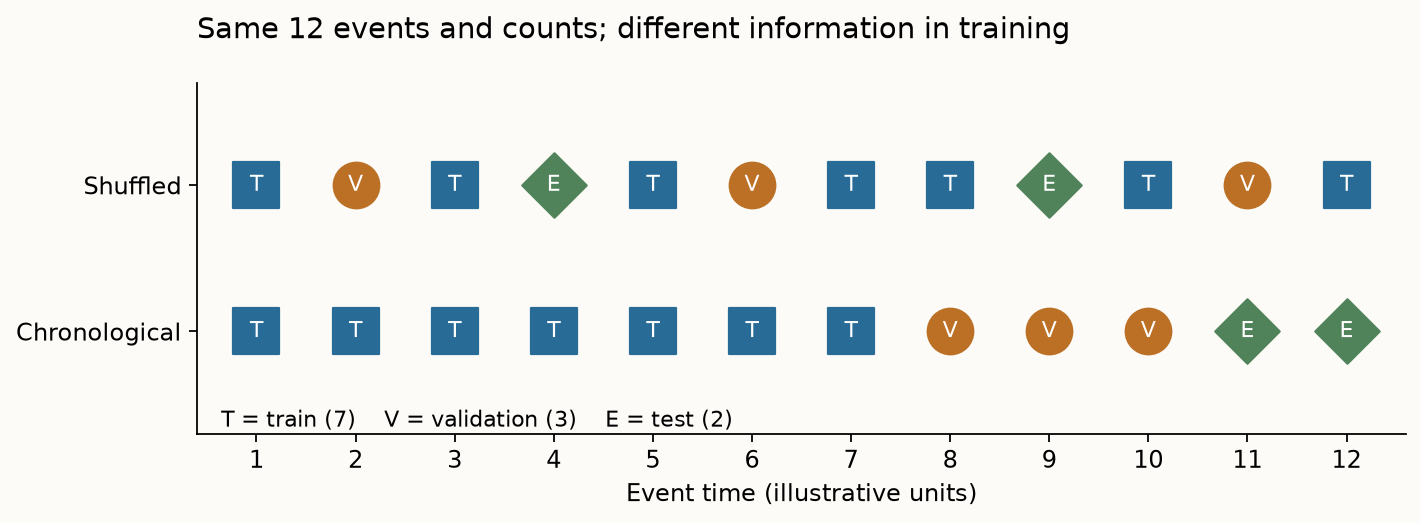

Illustration: identical twelve events and 7/3/2 counts, different memberships. T=train, V=validation, E=test.

### TODO 1 · Keep entire timestamp groups together
Return a dict of original row indices (`train`, `val`, `test`) for the half-open intervals in the lesson. Input may be unsorted. Reject non-increasing boundaries and empty partitions. Do not access labels. This exercise is a stricter alternative to the released index arrays; the experiment retains the released arrays and audits their boundary ties.

In [ ]:
# TODO — chronological_split
def chronological_split(time, validation_start, test_start):
    raise NotImplementedError("Complete the live function")

In [ ]:
# CHECK — unsorted inputs and shared timestamps
t=np.array([4,1,3,2,3,6,5,7,8,9])
s=chronological_split(t,4,7)
assert set(s['train'])=={1,2,3,4}, 'Keep both events at time 3 in training'
assert set(s['val'])=={0,5,6} and set(s['test'])=={7,8,9}
assert max(t[s['train']]) < min(t[s['val']])
print('PASS: ties stay together, original indices preserved')

## 3. An event timestamp is only one clock




A prediction has at least three relevant times: when the event occurs, when each feature becomes available, and when its label arrives. A loan made on Monday can default months later. A model fitted Tuesday cannot train on that Monday loan's eventual default label, even though the event is in the past. Likewise, a transaction's eventual settlement status is not a feature available at authorization.




Our worked example fits weights at time 8 and selects a candidate at time 11. Training events are 1–7, validation events 8–10. With label delay 3, event 6's label arrives at 9, too late for weight fitting. Only validation event 8's label arrives by the selection deadline 11. Availability exactly at a deadline is allowed in this illustration. Test labels are read later for scoring.




**Predict:** how many labels become usable if delay falls from 3 to 1? Move the slider, then trace event 6 in the table. Event partitions stay fixed; the available information changes.






This is a synthetic availability audit, not an accusation about these datasets. The released arrays expose event metadata but do not establish per-feature availability or label delay. Our experiment assumes their released features and labels are suitable for the benchmark. For a deployment claim, obtain that provenance separately. A temporal gap may help accommodate delays, but its size must follow the actual information horizon.

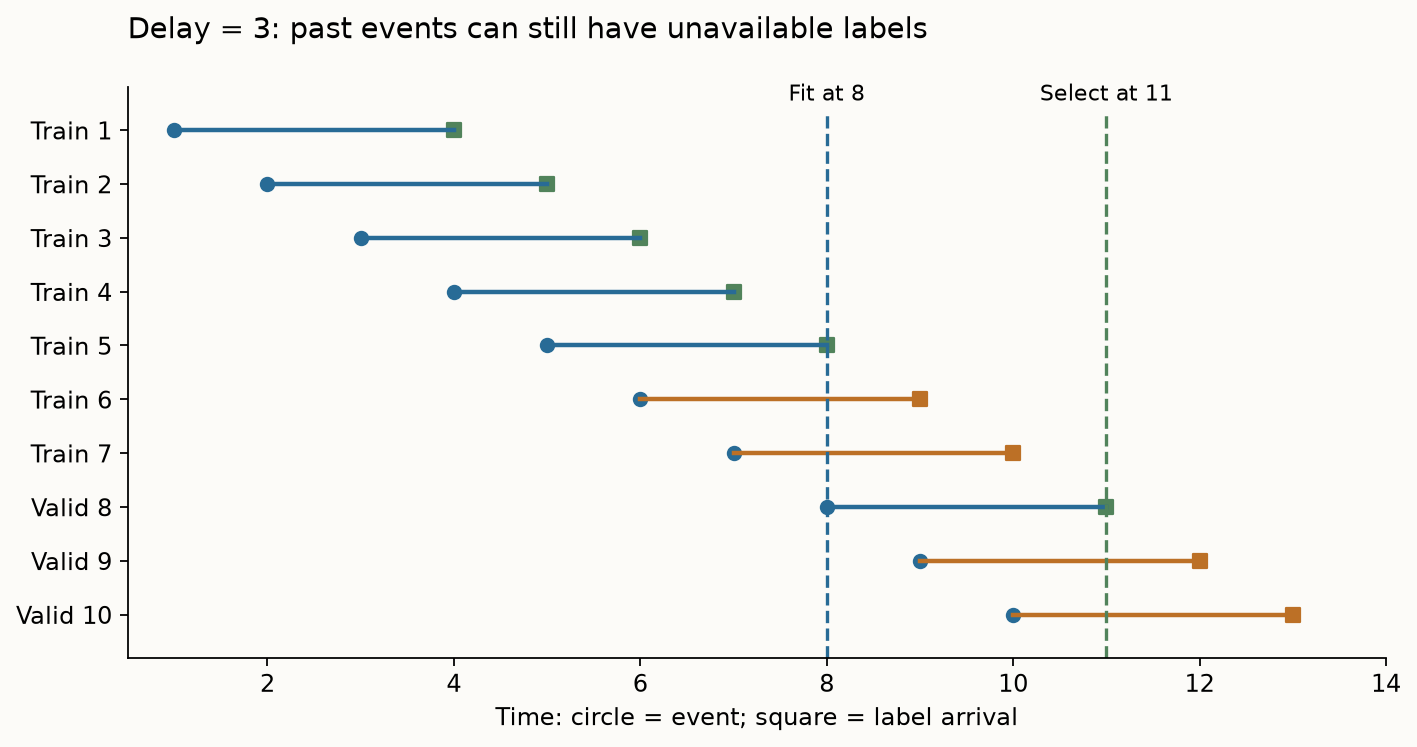

Illustrative delay=3: fit at 8 uses 5 training labels; selection at 11 uses 1 validation label. Test labels are scored later.

In [ ]:
# CHECK / prediction — alter DELAY after predicting the eligible counts
DELAY=3
event=np.arange(1,11);label_available=event+DELAY
fit_eligible=(event<8)&(label_available<=8)
select_eligible=(event>=8)&(label_available<=11)
print('Training labels:',fit_eligible.sum(),'Validation labels:',select_eligible.sum())
if DELAY==3: assert (fit_eligible.sum(),select_eligible.sum())==(5,1)
assert not fit_eligible[event==6].item() if DELAY==3 else True

## 4. Validation is inside the time boundary




**Training** fits weights and preprocessing. **Validation** chooses a candidate and a neural checkpoint (the stored weights after a training epoch). **Test** measures the already-selected procedure. Future validation labels can leak into the chosen model even when its gradient updates use only historical training rows.




Fit median imputation on training rows, replace missing values using those medians, then fit mean and standard deviation on the filled training matrix. Apply these frozen statistics to validation and test. If a training column is entirely missing, use zero; if its standard deviation is zero, use one as its scale. These conventions make the operation defined without consulting later rows. Regression targets are standardized using training statistics inside the neural trainer, then predictions are restored to the released target scale.






To study whether a validation protocol selects useful models, keep the final future test fixed and vary only how historical training/validation rows are assigned. That answers a narrower question than swapping both train and test populations. L055b will develop the validation-protocol thread further.

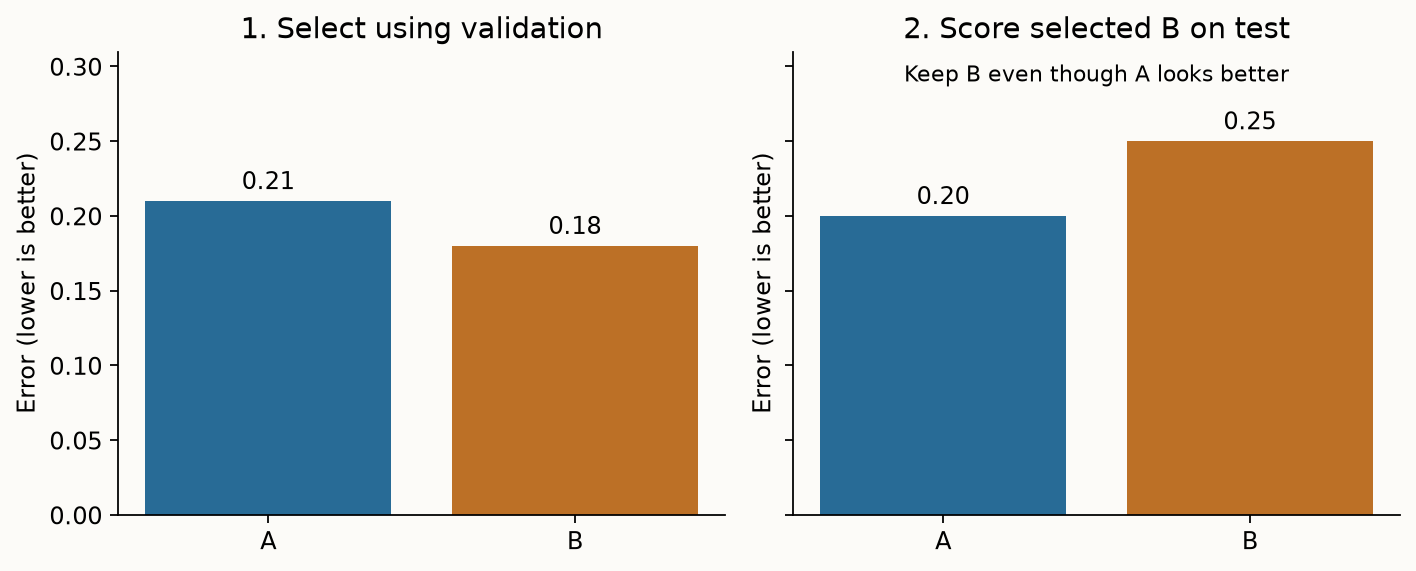

Illustration: validation selects B with .18 error; test error .25 remains the reported result even though A would score .20.

### TODO 2 · Fit preprocessing on training only
Return `(median, mean, scale)` arrays, one entry per column. Treat nonfinite entries as missing; use zero for an entirely missing training column. Compute mean/std after imputation, replacing zero std by one. The PROVIDED transform and every fitted model below consume your returned state. Changing test values must not change it.

In [ ]:
# TODO — fit_preprocessor
def fit_preprocessor(train):
    raise NotImplementedError("Complete the live function")

In [ ]:
# PROVIDED — apply frozen statistics
def apply_preprocessor(x, state):
    median, mean, scale = state
    return ((np.where(np.isfinite(x), x, median) - mean) / scale).astype('float32')

In [ ]:
# CHECK — held-out intervention and entirely missing training column
raw=np.array([[1.,np.nan],[3.,np.nan],[999.,9.]])
state=fit_preprocessor(raw[:2])
np.testing.assert_allclose(state[1],[2,0])
np.testing.assert_allclose(apply_preprocessor(raw[:2],state),[[-1,0],[1,0]])
changed=raw.copy();changed[2]=[-999999,888888]
for a,b in zip(state,fit_preprocessor(changed[:2])):np.testing.assert_allclose(a,b)
assert np.isfinite(apply_preprocessor(changed,state)).all()
print('PASS: held-out intervention cannot move fitted statistics')

### TODO 3 · Select before test
Return the index of the smallest validation error, resolving ties in favor of the first candidate. Reject empty/nonfinite input. No test argument is permitted. The neural trainer selects its checkpoint by validation; this function selects the candidate across its two hyperparameter settings.

In [ ]:
# TODO — select_candidate
def select_candidate(validation_errors):
    raise NotImplementedError("Complete the live function")

In [ ]:
# CHECK — test peeking gives the wrong selection
validation=[.21,.18];test=[.20,.25]
chosen=select_candidate(validation)
assert chosen==1 and test[chosen]==.25
assert select_candidate([.2,.2])==0
print('PASS: selected B; report .25 despite test temptation')

## 5. What TabReD establishes




TabReD adds eight feature-rich industrial tasks with temporal splits. Its split study uses three paired temporal/random splits and 15 initialization seeds, comparing MLP, MLP-PLR, XGBoost and TabR-S. It reports changed scores, relative margins and ranks; XGBoost's lead shrinks under temporal evaluation. This is not a universal tree-versus-neural ordering. [Source: §5.4, Figure 2.](https://arxiv.org/html/2406.19380v4#S5.SS4)




The full benchmark favors strong GBDTs and MLPs with numerical embeddings on average; retrieval gains from earlier benchmarks transfer unevenly. Temporal mismatch and feature complexity are possible explanations, not independently identified causes. [Source: §5.2–5.3.](https://arxiv.org/html/2406.19380v4#S5.SS2)




Distinguish the benchmark's broad model comparison from its split intervention. Our lab targets the latter skill. TabM-mini is a continuity baseline from L054, not one of Figure 2's original arms. We do not implement MLP-PLR or TabR here.

### PROVIDED · Existing model operations from L054
The protocol is the new mechanism here. For portability, inspect the complete model implementation below. `x` has shape [batch, features]; MLP produces [batch, outputs]. TabM broadcasts rows to [batch, k, features], applies shared blocks with member-specific input adapters and separate heads, and averages probabilities (classification) or values (regression). No label enters prediction. Numeric/binary inputs only; no embeddings. These are teaching baselines, not Figure 2's full model suite.

In [ ]:
# PROVIDED — member operations
def kaiming_(t):
    """nn.Linear-style init so the shared W starts like a plain MLP layer."""
    nn.init.kaiming_uniform_(t, a=math.sqrt(5))
    return t

def sign_pm1(k, d, generator=None):
    """Random ±1 initialisation for the first adapter (paper §3.2: diversity)."""
    return torch.where(torch.rand(k, d, generator=generator) < .5, -1., 1.)

def batchensemble_linear(x, weight, R, S, bias):
    """BatchEnsemble layer over k members (paper §3.2).

    x: [B, k, d_in]; weight (shared W): [d_in, d_out]; R: [k, d_in] or None;
    S: [k, d_out] or None; bias (B): [k, d_out]. Returns [B, k, d_out] computed as
    ((x ⊙ R) W) ⊙ S + B, with R/S skipped when None (the mini variant).
    """
    if R is not None:
        x = x * R
    h = torch.einsum('bki,io->bko', x, weight)
    if S is not None:
        h = h * S
    return h + bias

def packed_head(h, weight, bias):
    """k independent output heads. h: [B,k,d]; weight: [k,d,d_y]; bias: [k,d_y]."""
    return torch.einsum('bkd,kdo->bko', h, weight) + bias

def member_mean_loss(out, y, regression):
    """Mean over the k members of each member's loss (paper §5.1). out: [B,k,d_y]."""
    k = out.shape[1]
    if regression:
        return ((out[:, :, 0] - y.unsqueeze(1)) ** 2).mean()
    logp = out.log_softmax(-1)
    nll = -logp.gather(-1, y.view(-1, 1, 1).expand(-1, k, 1)).squeeze(-1)
    return nll.mean()

def ensemble_predict(out, regression):
    """Mean prediction over members: raw for regression, probabilities otherwise."""
    if regression:
        return out.mean(1)[:, 0]
    return out.softmax(-1).mean(1)

In [ ]:
# PROVIDED — MLP and shared layers
class MLP(nn.Module):
    """Plain MLP baseline: N blocks of Linear→ReLU→Dropout, then a linear head.

    This is both the k=1 reference and the member architecture of the deep
    ensemble MLP^{×k}. Definition follows paper §3.3.
    """
    def __init__(self, din, width=64, depth=3, dropout=.1, regression=False, k=1):
        super().__init__()  # k is accepted and ignored so MLP and TabM share a signature
        dims = [din] + [width] * depth
        self.blocks = nn.ModuleList(nn.Linear(a, b) for a, b in zip(dims[:-1], dims[1:]))
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(width, 1 if regression else 2)
        self.regression = regression

    def forward(self, x):
        h = x
        for block in self.blocks:
            h = self.dropout(torch.relu(block(h)))
        return self.head(h)

class BatchEnsembleLinear(nn.Module):
    """One shared W with per-member multiplicative (R,S) and additive (B) adapters.

    ``first`` selects the diversity-creating adapter that is initialised with
    random ±1; all other adapters are initialised so they have no effect at the
    start (R=S=1, B=0), matching the ``TabM`` initialisation in paper §3.3.
    ``shared_rs`` (used by the ``mini`` variant) drops the R and S adapters
    entirely for every layer except the first.
    """
    def __init__(self, din, dout, k, first=False, shared_rs=False, generator=None):
        super().__init__()
        self.k = k
        self.weight = nn.Parameter(kaiming_(torch.empty(din, dout)))
        self.bias = nn.Parameter(torch.zeros(k, dout))            # additive adapter B
        if shared_rs and not first:
            self.register_parameter('R', None)
            self.register_parameter('S', None)
        else:
            r0 = sign_pm1(k, din, generator) if first else torch.ones(k, din)
            self.R = nn.Parameter(r0)
            self.S = nn.Parameter(torch.ones(k, dout))

    def forward(self, x):                                          # x: [B, k, din]
        return batchensemble_linear(x, self.weight, self.R, self.S, self.bias)

class PackedHead(nn.Module):
    """k independent output heads (one per submodel); d_y is tiny so this is cheap."""
    def __init__(self, width, dy, k):
        super().__init__()
        self.weight = nn.Parameter(kaiming_(torch.empty(k, width, dy)))
        self.bias = nn.Parameter(torch.zeros(k, dy))

    def forward(self, h):                                          # h: [B, k, width]
        return packed_head(h, self.weight, self.bias)

In [ ]:
# PROVIDED — TabM complete forward path
class TabM(nn.Module):
    """One model imitating an ensemble of k MLPs (paper §3.3).

    forward returns per-member outputs of shape [B, k, d_y]. Use
    :meth:`predict` for the mean (ensemble) prediction and :meth:`member_losses`
    for the mean-over-members training objective.
    """
    def __init__(self, din, k=32, width=64, depth=3, dropout=.1,
                 regression=False, arch='mini', seed=0):
        super().__init__()
        assert arch in ('mini', 'tabm')
        g = torch.Generator().manual_seed(seed)
        self.k, self.regression, self.arch = k, regression, arch
        dims = [din] + [width] * depth
        shared_rs = arch == 'mini'
        self.blocks = nn.ModuleList(
            BatchEnsembleLinear(a, b, k, first=(i == 0), shared_rs=shared_rs, generator=g)
            for i, (a, b) in enumerate(zip(dims[:-1], dims[1:])))
        self.dropout = nn.Dropout(dropout)
        self.head = PackedHead(width, 1 if regression else 2, k)

    def forward(self, x):
        h = x.unsqueeze(1).expand(-1, self.k, -1)                 # [B,k,din], k shared copies
        for block in self.blocks:
            h = self.dropout(torch.relu(block(h)))
        return self.head(h)                                       # [B,k,d_y]

    def predict(self, x):
        """Ensemble prediction: mean over members (probabilities if classifying)."""
        return ensemble_predict(self(x), self.regression)

    def member_losses(self, x, y):
        """Mean over the k members of each member's supervised loss (paper §5.1)."""
        return member_mean_loss(self(x), y, self.regression)

    def member_predictions(self, x):
        """Per-member predictions [B,k,(d_y)] for individual-vs-collective analysis."""
        out = self(x)
        if self.regression:
            return out[:, :, 0]
        return out.softmax(-1)

### PROVIDED · Load released indices and audit before fitting
The first metadata column provides event ordering and is excluded from model features. The second Ecom metadata column is also excluded. Numeric and binary columns are concatenated; categorical columns are omitted explicitly. All models use identical capped rows within each protocol. The full released row pool is identical across a random/sliding pair; independently capped memberships differ.

In [ ]:
TASKS=('ecom-offers','homesite-insurance','sberbank-housing')
ARMS=('MLP','TabM-mini','XGBoost')
def load_release(name, strategy, split_id=0, train_cap=1500, eval_cap=600, root='data/cache/l055'):
    folder = Path(root) / name / name
    reg = json.loads((folder / 'info.json').read_text())['task']['type'] == 'regression'
    matrices = [np.load(folder / (k + '.npy'), mmap_mode='r') for k in ('x_num', 'x_bin') if (folder / (k + '.npy')).exists()]
    y = np.load(folder / 'y.npy')
    timestamps = np.load(folder / 'x_meta.npy', mmap_mode='r')[:, 0]
    split_name = ('random-' if strategy == 'random' else 'sliding-window-') + str(split_id)
    all_ids = {s: np.load(folder / 'splits' / split_name / (s + '.npy')) for s in ('train', 'val', 'test')}
    assert sum(map(len, all_ids.values())) == len(np.unique(np.concatenate(list(all_ids.values()))))
    ids = {}
    for i, s in enumerate(all_ids):
        cap = train_cap if s == 'train' else eval_cap
        pool = all_ids[s]
        ids[s] = np.sort(np.random.default_rng(550 + i).choice(pool, min(cap, len(pool)), replace=False))
    x = {s: np.concatenate([m[idx] for m in matrices], axis=1) for s, idx in ids.items()}
    audit = dict(split=split_name, full_sizes={s: len(v) for s, v in all_ids.items()},
                 sizes={s: len(v) for s, v in ids.items()}, features=x['train'].shape[1],
                 omitted_categorical_features=(np.load(folder/'x_cat.npy', mmap_mode='r').shape[1] if (folder/'x_cat.npy').exists() else 0),
                 time_ranges={s: [int(timestamps[v].min()), int(timestamps[v].max())] for s, v in ids.items()},
                 index_hashes={s: hashlib.sha256(v.tobytes()).hexdigest() for s, v in ids.items()})
    if strategy == 'temporal':
        for a, b in [('train','val'), ('val','test')]:
            assert timestamps[all_ids[a]].max() <= timestamps[all_ids[b]].min(), 'Released temporal split is not ordered'
        audit['strict_time_boundaries'] = all(timestamps[all_ids[a]].max() < timestamps[all_ids[b]].min() for a,b in [('train','val'),('val','test')])
    return x, {s: y[v] for s,v in ids.items()}, reg, audit

def metric(y, prediction, regression):
    return float(np.sqrt(np.mean((y-prediction)**2))) if regression else float(1-roc_auc_score(y, prediction))

In [ ]:
# CHECK — actual release geometry, then compare your strict splitter
audit_rows=[]
for name in TASKS:
    d=DATA_ROOT/name/name
    ids={mode:{s:np.load(d/'splits'/mode/(s+'.npy')) for s in ('train','val','test')} for mode in ('random-0','sliding-window-0')}
    pools=[np.sort(np.concatenate(list(v.values()))) for v in ids.values()]
    np.testing.assert_array_equal(*pools)
    assert [len(v) for v in ids['random-0'].values()]==[len(v) for v in ids['sliding-window-0'].values()]
    t=np.load(d/'x_meta.npy')[:,0];given=ids['sliding-window-0']
    a=t[given['val']].min();b=t[given['test']].min()
    strict=chronological_split(t[pools[0]],a,b)
    _,_,_,audit=load_release(name,'temporal',root=DATA_ROOT)
    audit_rows.append(dict(task=name,released_train=len(given['train']),strict_train=len(strict['train']),strict_release=audit['strict_time_boundaries']))
display(pd.DataFrame(audit_rows))
print('False means a shared boundary timestamp, not a reversed timeline.')

### PROVIDED · Fit weights and select checkpoints
Each neural candidate sees only train and validation. Fit regression scaling on training labels. Run a shuffled training minibatch loop; store the first best validation checkpoint. Restore it before returning a predictor. The next stage fits two candidates, calls your selector, then makes test predictions only for the selected candidate.

In [ ]:
# PROVIDED — complete neural trainer
def fit_neural(x, y, reg, arm, seed, width=64, epochs=32, lr=.001, k=8):
    """Training and checkpoint selection receive train/validation only."""
    torch.manual_seed(seed)
    xs = {s: torch.tensor(v) for s,v in x.items()}
    mu, sd = (float(y['train'].mean()), max(float(y['train'].std()), 1e-8)) if reg else (0., 1.)
    target = torch.tensor((y['train']-mu)/sd, dtype=torch.float32 if reg else torch.long)
    cls = TabM if arm == 'TabM-mini' else MLP
    kwargs = dict(din=x['train'].shape[1], width=width, depth=2, dropout=.1, regression=reg, k=k)
    if arm == 'TabM-mini': kwargs.update(arch='mini', seed=seed)
    model = cls(**kwargs)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    def predict(values):
        model.eval()
        with torch.no_grad():
            out = model.predict(values) if arm == 'TabM-mini' else model(values)
            if arm == 'MLP': out = out[:,0] if reg else out.softmax(-1)
            out = out.numpy()
        return out*sd+mu if reg else out[:,1]
    best, state, best_epoch = float('inf'), None, None
    for epoch in range(epochs):
        model.train()
        for idx in torch.randperm(len(target)).split(256):
            if arm == 'TabM-mini': loss = model.member_losses(xs['train'][idx], target[idx])
            else:
                out = model(xs['train'][idx])
                loss = nn.functional.mse_loss(out[:,0], target[idx]) if reg else nn.functional.cross_entropy(out, target[idx])
            if not torch.isfinite(loss): raise RuntimeError('Nonfinite training loss')
            opt.zero_grad(); loss.backward(); opt.step()
        val = metric(y['val'], predict(xs['val']), reg)
        if val < best:
            best, state, best_epoch = val, copy.deepcopy(model.state_dict()), epoch+1
    model.load_state_dict(state)
    return lambda values: predict(torch.tensor(values)), best, best_epoch

In [ ]:
# PROVIDED — validation-only candidate selection
def evaluate_arm(x, y, reg, arm, seed, epochs=32, trees=120):
    """Two candidates; validation selects before test predictions are computed."""
    candidates = []
    for candidate in range(2):
        if arm == 'XGBoost':
            cls = XGBRegressor if reg else XGBClassifier
            model = cls(n_estimators=trees, max_depth=(3,6)[candidate], learning_rate=.05,
                        subsample=.8, colsample_bytree=.8, n_jobs=1, random_state=seed, tree_method='hist')
            model.fit(x['train'], y['train'])
            predict = model.predict if reg else lambda values, m=model: m.predict_proba(values)[:,1]
            val, epoch = metric(y['val'], predict(x['val']), reg), None
        else:
            predict, val, epoch = fit_neural({s:x[s] for s in ('train','val')}, {s:y[s] for s in ('train','val')},
                                           reg, arm, seed, epochs=epochs, lr=(.001,.003)[candidate])
        candidates.append((predict, val, epoch))
    selected = select_candidate([c[1] for c in candidates])
    predict, val, epoch = candidates[selected]
    pred = predict(x['test'])
    return dict(seed=seed, selected=selected, validation_errors=[c[1] for c in candidates], best_epoch=epoch,
                error=metric(y['test'], pred, reg), predictions=pred.tolist())

In [ ]:
# PROVIDED — shared experiment and dataset-unit summaries
def run_suite(names=TASKS, seeds=(0,1,2), split_ids=(0,), train_cap=1500, eval_cap=600,
              epochs=32, trees=120, root='data/cache/l055'):
    torch.set_num_threads(1)
    start = time.perf_counter()
    result = dict(verdict='INCOMPARABLE', config=dict(names=list(names), seeds=list(seeds), split_ids=list(split_ids),
                  train_cap=train_cap, eval_cap=eval_cap, epochs=epochs, trees=trees, row_sampling_seeds=[550,551,552]),
                  versions={p:importlib.metadata.version(p) for p in ('torch','numpy','scipy','scikit-learn','xgboost')},
                  tasks={})
    with threadpool_limits(limits=1):
        for name in names:
            result['tasks'][name] = {}
            for strategy in ('random','temporal'):
                records = []
                for split_id in split_ids:
                    raw, y, reg, audit = load_release(name,strategy,split_id,train_cap,eval_cap,root)
                    state = fit_preprocessor(raw['train'])
                    x = {s:apply_preprocessor(v,state) for s,v in raw.items()}
                    record = dict(audit=audit, metric='RMSE of released log target' if reg else '1 - AUROC',
                                  test_targets=y['test'].tolist(), arms={})
                    for arm in ARMS:
                        record['arms'][arm] = [evaluate_arm(x,y,reg,arm,seed,epochs,trees) for seed in seeds]
                        print(name,strategy,split_id,arm,round(np.mean([v['error'] for v in record['arms'][arm]]),5),flush=True)
                    records.append(record)
                result['tasks'][name][strategy] = records
    result['seconds'] = time.perf_counter()-start
    return result

def summarize(result):
    """Average seeds then split windows within each task; datasets are rank units."""
    summary = {}
    for strategy in ('random','temporal'):
        errors = np.array([[np.mean([v['error'] for rec in task[strategy] for v in rec['arms'][arm]])
                            for arm in ARMS] for task in result['tasks'].values()])
        ranks = rankdata(errors,axis=1)
        n,k = errors.shape
        summary[strategy] = dict(errors=errors.tolist(), ranks=ranks.tolist(), mean_ranks=ranks.mean(0).tolist())
        if n >= 3:
            summary[strategy].update(friedman_p=float(friedmanchisquare(*errors.T).pvalue),
                nemenyi_cd=float(studentized_range.ppf(.95,k,np.inf)/np.sqrt(2)*np.sqrt(k*(k+1)/(6*n))))
    return summary

In [ ]:
# CHECK — prove the experiment calls YOUR live preprocessor and selector
# Small real-data run; these counters wrap the functions above, not relkit imports.
calls={'preprocess':0,'select':0}
saved_preprocessor=fit_preprocessor;saved_selector=select_candidate
def fit_preprocessor(train):
    calls['preprocess']+=1
    return saved_preprocessor(train)
def select_candidate(values):
    calls['select']+=1
    return saved_selector(values)
try:
    smoke=run_suite(names=('sberbank-housing',),seeds=(0,),train_cap=300,eval_cap=150,epochs=2,trees=10,root=DATA_ROOT)
finally:
    fit_preprocessor=saved_preprocessor;select_candidate=saved_selector
assert calls=={'preprocess':2,'select':6}, calls
print('PASS: six selected fits used the live functions',calls)

## 6. Run the comparison, then accept its answer




**Held fixed:** three released task pools, matching partition counts, label-blind row caps, feature policy, two candidates per arm and three training seeds. **Varied:** random-0 versus sliding-window-0, including their validation assignment. **Measured:** 1−AUROC for classification and RMSE for regression, so lower is better throughout. AUROC is the probability that a positive example receives a larger score than a negative example, counting ties by half. RMSE is √mean((prediction−target)²), in target units. Sberbank's released target is log(price / floor area), as defined in the [pinned preprocessing code](https://github.com/yandex-research/tabred/blob/b5ef15b3749f30da7a1eb8fba21a5b54d706bf32/preprocessing/sberbank_housing.py); its RMSE is not a currency error.




We use Ecom Offers, Homesite Insurance and Sberbank Housing from the July 2026 public release, verified against the [pinned official registry](https://github.com/yandex-research/tabred/blob/b5ef15b3749f30da7a1eb8fba21a5b54d706bf32/src/tabred/registry.py). These files' row/feature counts differ from the paper's Table 2, so “official download” does not establish paper-version equality.




Caps are 1500 training / 600 validation / 600 test rows per protocol; sampling seeds 550/551/552 are independent of labels and model seeds 0/1/2. Numeric and binary columns are kept; 23 Homesite and 10 Sberbank categorical columns are omitted. MLP and TabM-mini use two width-64 blocks, 32 epochs, AdamW, and candidate learning rates .001/.003; TabM has k=8. XGBoost uses 120 trees with candidate depths 3/6. Candidate budgets match in count, not compute or search-space coverage. Median/standard scaling differs from the paper's quantile preprocessing. Five other tasks, larger searches, full features and repeated temporal windows are omitted from this local run.






For three seed errors *e₁,e₂,e₃*, report their mean and sample standard deviation *s*. The plotted interval is mean ± 4.303·s/√3 (Student-t with two degrees of freedom). It conditions on fixed rows and protocol; it does not include future-period uncertainty. Random and temporal test rows differ, so paired seed numbers are not paired observations. Do not treat their score difference as a per-example paired test.




Our Friedman test asks about consistent rank differences across the **three datasets**, separately for each protocol. Nemenyi's critical difference marks a pairwise rank separation threshold. These are exploratory summaries, not the paper's statistical procedure or a powered robustness claim. The [reproduction contract](l055-reproduction.md) records the scope; raw scores, predictions and selection traces are in [the evidence JSON](_verify_l055_results.json).

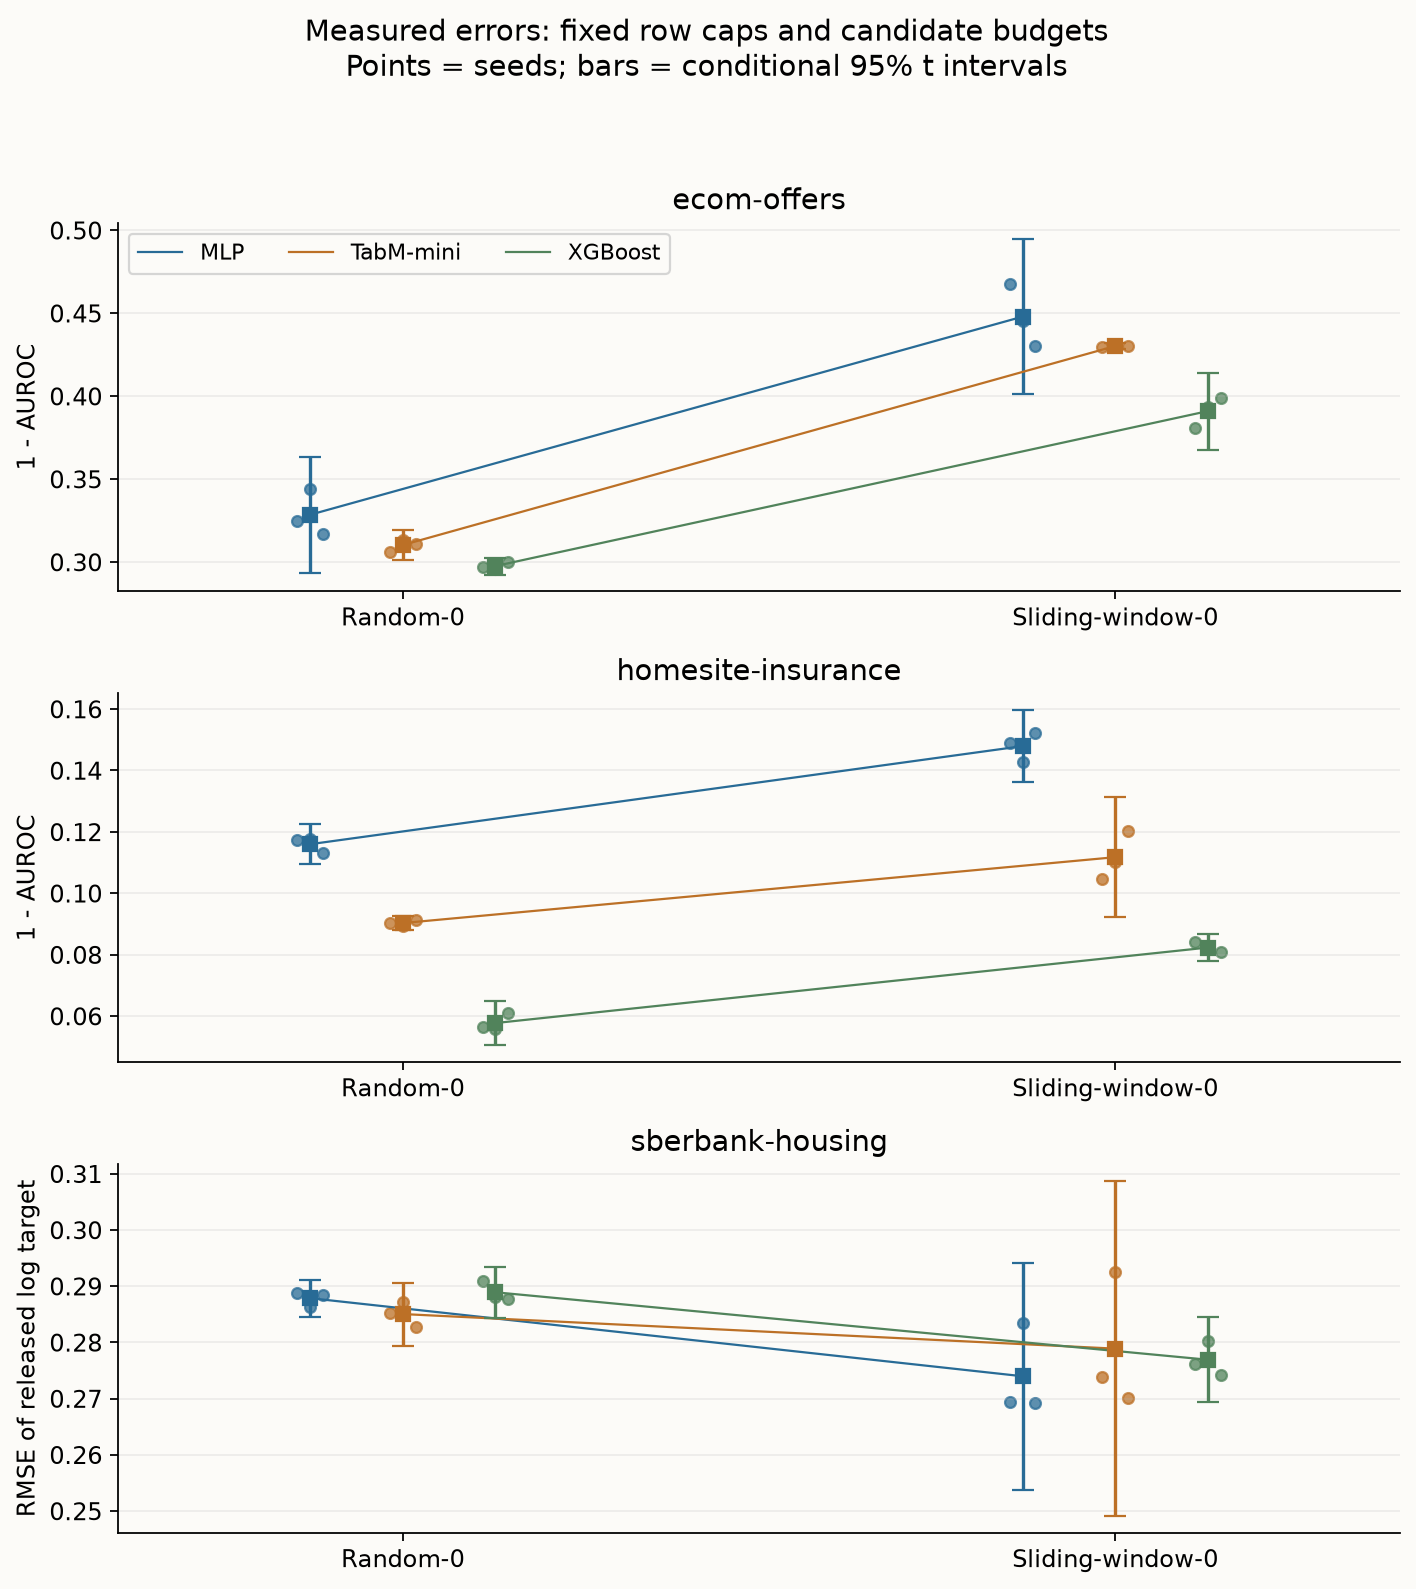

Author-reference errors: seed points and conditional 95% t intervals on fixed released split pair 0; INCOMPARABLE to Figure 2.

### Predict before fitting
Write which margin you expect to change and why. Do not change the random seed to force a reversal. The cell below reruns the complete local protocol; your result is authoritative for your environment.

In [ ]:
# PROVIDED — your current experiment (all three seeds)
result=run_suite(root=DATA_ROOT)
result['summary']=summarize(result)
(DATA_ROOT/'student-results.json').write_text(json.dumps(result,indent=1))
rows=[]
for name,task in result['tasks'].items():
    for strategy,records in task.items():
        for arm in ARMS:
            errors=np.array([v['error'] for v in records[0]['arms'][arm]])
            rows.append(dict(task=name,protocol=strategy,model=arm,mean=errors.mean(),sd=errors.std(ddof=1),ci95_halfwidth=4.30265273*errors.std(ddof=1)/np.sqrt(len(errors))))
table=pd.DataFrame(rows);display(table.round(5))
print('Mean ± sample SD; intervals condition on one split and three model seeds.')

### TODO 4 · Rank datasets before averaging
Input is one task's vector of seed-mean errors for each protocol, in ARMS order. Return temporal ranks minus random ranks (average ties). Lower error earns a better rank; positive output means worse relative placement. This is a change in relative placement, not an error difference.

In [ ]:
# TODO — rank_change
def rank_change(random_errors, temporal_errors):
    raise NotImplementedError("Complete the live function")

In [ ]:
# CHECK — direction, ties and actual results
np.testing.assert_array_equal(rank_change([.1,.2,.3],[.3,.2,.1]),[2,0,-2])
np.testing.assert_array_equal(rank_change([.1,.1,.3],[.1,.1,.3]),[0,0,0])
random_errors=np.array(result['summary']['random']['errors'])
time_errors=np.array(result['summary']['temporal']['errors'])
changes=np.array([rank_change(a,b) for a,b in zip(random_errors,time_errors)])
display(pd.DataFrame(changes,index=list(result['tasks']),columns=ARMS))
print('Mean-rank changes:',dict(zip(ARMS,changes.mean(0))))
for strategy,s in result['summary'].items():
    print(strategy,'Friedman p:',s['friedman_p'],'Nemenyi CD:',s['nemenyi_cd'])

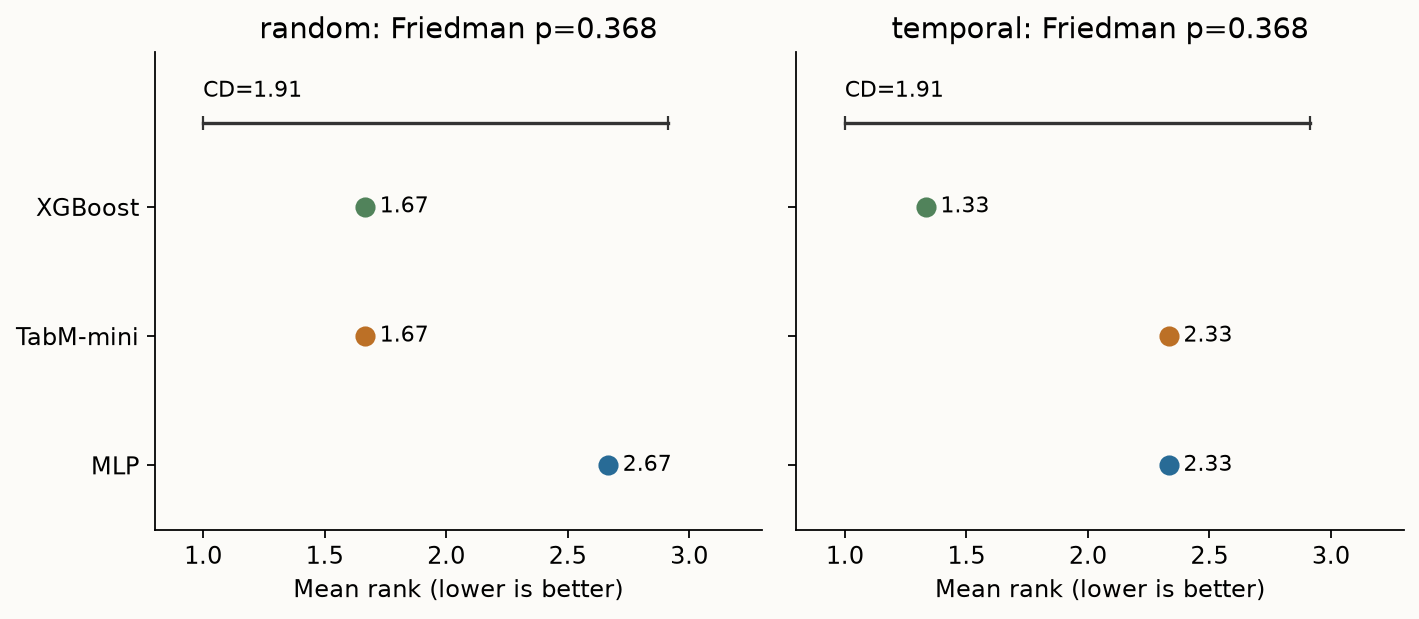

Author-reference mean ranks across THREE task units; Nemenyi critical difference. Training seeds are not additional datasets.

### EXIT TICKET · Hand in an audit, not a winner story
1. Include your timestamp audit and explain the difference between shared boundary timestamps and unavailable labels.
2. Give one task's three-model random/time errors with sample SD; state whether its winner changes.
3. Quantify a margin change and explain why it is a protocol effect, not isolated causal drift evidence.
4. Name what seed intervals omit and one experiment that addresses it.
5. Write separate **verified here / paper claim / scale-up** statements. The paper verdict remains **INCOMPARABLE**.

Paste this output and your explanation to the tutor for feedback. No automatic mastery credit is awarded for running the solution.

In [ ]:
# EXIT — replace the text, retaining your measured table and audits
explanation="WRITE your interpretation before submitting"
exit_ticket=dict(audit=audit_rows,table=table.to_dict(orient='records'),rank_changes=changes.tolist(),explanation=explanation,verdict='INCOMPARABLE')
(DATA_ROOT/'exit.json').write_text(json.dumps(exit_ticket,indent=1))
print('Saved',DATA_ROOT/'exit.json')

### Required next step · more temporal windows, same live code
After completing EXIT, run this larger comparison. It uses three paired released windows, three model seeds, 6000/2000/2000 caps, 64 epochs and 300 trees. This probes split stability while staying within the same numeric/binary teaching implementation. It still differs from Figure 2 in models, feature policy, tuning, repetitions and data version. **NOT_RUN until you run it.**

The cell deliberately calls the functions currently in this notebook. A CPU cloud alternative is `modal run --detach modal/l055_paper_repro.py --preset closer` from the repository root. The full paper experiment is a separate, unrun reconstruction, described in the reproduction contract.

In [ ]:
# PROVIDED — gated scale-up; uses your live functions
RUN_PAPER_REPRO=False
if RUN_PAPER_REPRO:
    closer=run_suite(root=DATA_ROOT,split_ids=(0,1,2),train_cap=6000,eval_cap=2000,epochs=64,trees=300)
    closer['summary']=summarize(closer)
    closer['verdict']='INCOMPARABLE'
    (DATA_ROOT/'closer-results.json').write_text(json.dumps(closer,indent=1))
    display(pd.DataFrame({s:v['mean_ranks'] for s,v in closer['summary'].items()},index=ARMS))
else:
    print('Scale-up NOT_RUN. Full paper Figure 2 NOT_RUN. Local evidence INCOMPARABLE.')